In [1]:
# Classificação Automática de Atividades Culturais e Educacionais
# 05 - Clusterização com embeddings
#
# Integrantes: Beatriz Aparecida de Mello Barbosa (10354067), Bruna Gonçalves Corte David (10425696),
#              Henrique Brainer Costa (10420717), João Pedro Queiroz de Andrade (10425822),
#              Júlia Andrade (10428513)
#
# Conteúdo: agrupa as atividades pelos embeddings, compara o resultado com o agrupamento por TF-IDF
#           e monta a tabela de grupos que o time usa para dar nome às categorias novas.
#
# Alterações:
#   2026-09-25 - Bruna - notebook novo, com a clusterização por embeddings e os nomes que demos
#                        aos grupos na revisão manual

In [2]:
# ====================================================================================================
#                                CARREGAMENTO DOS VETORES
# ====================================================================================================
import pandas as pd                                                   # leitura e manipulação das tabelas
import numpy as np                                                    # contas com vetores e matrizes
import matplotlib.pyplot as plt                                       # gráficos que vão para o artigo
from sklearn.cluster import KMeans                                    # agrupa por proximidade, sem usar categoria nenhuma
from sklearn.metrics import silhouette_score                          # mede se cada atividade ficou mais perto do próprio grupo que dos outros

activities = pd.read_csv("../data/processed/activities_clustered_tfidf.csv", sep=";", encoding="utf-8-sig")   # traz junto o agrupamento do notebook 04
activity_embeddings = np.load("../data/processed/embeddings.npy")                                             # vetores gerados no notebook 03

print("Atividades:", len(activities), "| Formato dos embeddings:", activity_embeddings.shape)

Atividades: 693 | Formato dos embeddings: (693, 1024)


In [3]:
# ====================================================================================================
#                        QUANTOS GRUPOS? A MESMA PERGUNTA, OUTRA REPRESENTAÇÃO
# ====================================================================================================
silhouette_per_k = {}                                                 # número de grupos -> qualidade do agrupamento
for number_of_clusters in range(4, 21):
    test_kmeans = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)                 # semente fixa para o resultado se repetir
    test_clusters = test_kmeans.fit_predict(activity_embeddings)                                    # em que grupo cada atividade caiu
    silhouette_per_k[number_of_clusters] = silhouette_score(activity_embeddings, test_clusters)      # quanto maior, mais separados os grupos

silhouette_per_k = pd.Series(silhouette_per_k)                                                      # vira série para plotar
silhouette_per_k.round(4)

4     0.0533
5     0.0502
6     0.0525
7     0.0495
8     0.0528
9     0.0396
10    0.0393
11    0.0434
12    0.0438
13    0.0413
14    0.0413
15    0.0508
16    0.0425
17    0.0426
18    0.0399
19    0.0451
20    0.0405
dtype: float64

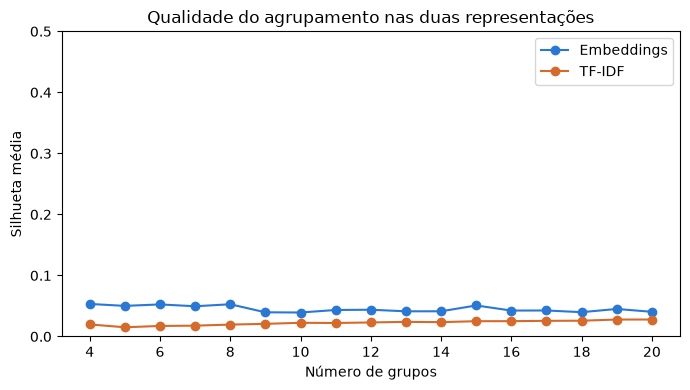

In [4]:
# ----------------------------------------------------------------------------------------------------
#                   GRÁFICO: AS DUAS REPRESENTAÇÕES LADO A LADO, NA MESMA ESCALA
# ----------------------------------------------------------------------------------------------------
tfidf_silhouette = pd.read_csv("../data/processed/silhouette_tfidf.csv", index_col=0)["silhouette"]                       # valores calculados no notebook 04

plt.figure(figsize=(7, 4))                                                                                                # tamanho do gráfico em polegadas
plt.plot(silhouette_per_k.index, silhouette_per_k.values, marker="o", color="#2a78d6", label="Embeddings")                 # curva da representação principal
plt.plot(tfidf_silhouette.index, tfidf_silhouette.values, marker="o", color="#d66a2a", label="TF-IDF")                     # curva da representação de comparação
plt.ylim(0, 0.5)                                                                                                          # escala inteira da silhueta útil
plt.xlabel("Número de grupos")                                                                                            # rótulo do eixo horizontal
plt.ylabel("Silhueta média")                                                                                              # rótulo do eixo vertical
plt.title("Qualidade do agrupamento nas duas representações")                                                             # título que vai junto no artigo
plt.legend()                                                                                                              # identifica as duas curvas
plt.tight_layout()                                                                                                        # evita cortar os rótulos
plt.savefig("../paper/latex/figures/silhouette_embeddings_vs_tfidf.png", dpi=150)                                          # figura usada no artigo
plt.show()

In [5]:
number_of_clusters = 16                                                                          # mesmo número do notebook 04, para a comparação ser justa

kmeans = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)                        # semente fixa: rodando de novo dá o mesmo resultado
activities["cluster"] = kmeans.fit_predict(activity_embeddings)                                   # em que grupo cada atividade caiu

activities_per_cluster = activities["cluster"].value_counts().sort_index()                        # tamanho de cada grupo
activities_per_cluster

cluster
0     45
1     54
2     36
3     47
4     26
5     36
6     54
7     40
8     59
9     48
10    56
11    21
12    64
13    17
14    40
15    50
Name: count, dtype: int64

In [6]:
# ====================================================================================================
#           OS GRUPOS AINDA SE FORMAM POR INSTITUIÇÃO? A MESMA CONFERÊNCIA DO NOTEBOOK 04
# ====================================================================================================
source_per_cluster = pd.crosstab(activities["cluster"], activities["source"])                                  # quantas atividades de cada instituição em cada grupo

largest_source_in_cluster = source_per_cluster.max(axis=1)                                                     # instituição dominante de cada grupo
cluster_sizes = source_per_cluster.sum(axis=1)                                                                 # tamanho total de cada grupo
dominance_with_embeddings = 100 * largest_source_in_cluster.sum() / cluster_sizes.sum()                         # média ponderada da dominância
share_of_largest_source = 100 * activities["source"].value_counts().iloc[0] / len(activities)                   # dominância que existiria sem vazamento nenhum

print("Sem vazamento nenhum, a dominância seria:", round(share_of_largest_source, 1), "%")
print("Dominância com embeddings:", round(dominance_with_embeddings, 1), "%")
print("Grupos com 90% ou mais de uma única instituição:", (largest_source_in_cluster / cluster_sizes >= 0.9).sum(), "de", number_of_clusters)
source_per_cluster

Sem vazamento nenhum, a dominância seria: 81.4 %
Dominância com embeddings: 83.5 %
Grupos com 90% ou mais de uma única instituição: 8 de 16


source,Fábricas de Cultura,SESC
cluster,,
0,14,31
1,1,53
2,18,18
3,15,32
4,0,26
5,2,34
6,4,50
7,4,36
8,0,59


Comparando com o notebook 04: lá a dominância foi 89,3% no TF-IDF cru e 86,1% depois de remover o
nome das instituições na mão. Aqui não removemos palavra nenhuma, porque não existe remover palavra de um
vetor de sentido. O que aparecer neste número veio da representação, e não de uma limpeza que a API
não poderia fazer.

In [7]:
# ----------------------------------------------------------------------------------------------------
#                   OS DOIS AGRUPAMENTOS CONCORDAM ENTRE SI?
# ----------------------------------------------------------------------------------------------------
from sklearn.metrics import adjusted_rand_score                                                                  # 1 é agrupar igual, 0 é concordar por acaso

agreement_between_clusterings = adjusted_rand_score(activities["cluster_tfidf_no_institution"], activities["cluster"])   # o quanto os dois agruparam igual

print("Concordância entre o agrupamento por TF-IDF e o por embeddings:", round(agreement_between_clusterings, 3))

Concordância entre o agrupamento por TF-IDF e o por embeddings: 0.21


Um valor baixo quer dizer que trocar a representação não foi ajuste fino. Os dois métodos recortam a
base de maneiras diferentes, e as atividades que caem juntas num não caem juntas no outro.

In [8]:
# ====================================================================================================
#                      O QUE CARACTERIZA CADA GRUPO: PALAVRAS E EXEMPLOS
# ====================================================================================================
from sklearn.feature_extraction.text import TfidfVectorizer          # aqui serve só para descrever os grupos, não para formá-los
from nltk.corpus import stopwords                                    # palavras comuns do português

portuguese_stopwords = stopwords.words("portuguese")                                       # mesma configuração dos outros notebooks
tfidf_for_description = TfidfVectorizer(stop_words=portuguese_stopwords, min_df=3)          # peso de cada palavra em cada atividade
description_matrix = tfidf_for_description.fit_transform(activities["text"])                # matriz usada só para ler os grupos
vocabulary_words = tfidf_for_description.get_feature_names_out()                            # nome de cada coluna

terms_per_cluster = {}                                                                      # grupo -> palavras que mais aparecem nele
for cluster_number in range(number_of_clusters):
    rows_of_the_cluster = (activities["cluster"] == cluster_number).values                  # quais linhas pertencem ao grupo
    average_weight_in_cluster = pd.Series(description_matrix[rows_of_the_cluster].mean(axis=0).A1, index=vocabulary_words)   # peso médio de cada palavra dentro do grupo
    terms_per_cluster[cluster_number] = ", ".join(average_weight_in_cluster.sort_values(ascending=False).head(12).index)     # as 12 palavras que mais o definem

print("Palavras características calculadas para", len(terms_per_cluster), "grupos")

Palavras características calculadas para 16 grupos


As palavras aqui são só legenda. Os grupos foram formados pelos embeddings, e o TF-IDF entra depois
para dizer quais palavras aparecem mais dentro de cada grupo já pronto.

In [9]:
for cluster_number in range(number_of_clusters):
    cluster_activities = activities[activities["cluster"] == cluster_number]                     # só as atividades desse grupo
    previous_categories = cluster_activities["original_categories"].dropna().str.split("|").explode().str.strip().value_counts().head(3)   # como os sites classificavam essas mesmas atividades
    print("=" * 100)
    print("GRUPO", cluster_number, "-", len(cluster_activities), "atividades  (SESC:", source_per_cluster.loc[cluster_number, "SESC"], "| Fábricas:", source_per_cluster.loc[cluster_number, "Fábricas de Cultura"], ")")
    print("PALAVRAS:", terms_per_cluster[cluster_number])
    print("CATEGORIAS ANTIGAS MAIS COMUNS:", previous_categories.to_dict())
    for activity_title in cluster_activities["title"].head(8):
        print("   -", activity_title)

GRUPO 0 - 45 atividades  (SESC: 31 | Fábricas: 14 )
PALAVRAS: histórias, livro, livros, leitura, biblioteca, encontro, sobre, literatura, contos, novos, escrita, autora
CATEGORIAS ANTIGAS MAIS COMUNS: {'Encontros e Palestras': 19, 'Literatura': 19, 'Biblioteca': 12}
   - A TERRA DÁ, A TERRA QUER: RODA DE LEITURA E VIVÊNCIA COLETIVA – COM EQUIPE BIBLIOTECA
   - CONTAÇÃO DE HISTÓRIA: HISTÓRIAS VIAJANTES – COM CIA. DAS RUTES
   - ENCONTRO COM O AUTOR – ROMEU E JULIETA A PRIMEIRA VERSÃO IN-QUARTO COM RICARDO CARDOSO
   - SANKOFA: CAÇA AO TESOURO ANCESTRAL – COM EQUIPE BIBLIOTECA
   - PALAVRA VIVA: PROVÉRBIOS, ADIVINHAS E SABEDORIA DE RODA – COM EQUIPE BIBLIOTECA
   - SESSÃO GEEK: ANIMES E CARTOONS NA BIBLIOTECA – COM EQUIPE BIBLIOTECA
   - CLUBINHO DO LIVRO: LEITURAS LGBTQIAPN+ – COM EQUIPE BIBLIOTECA
   - A GRANDE FÁBRICA DE PALAVRAS – COM EQUIPE BIBLIOTECA
GRUPO 1 - 54 atividades  (SESC: 53 | Fábricas: 1 )
PALAVRAS: yoga, movimento, aula, corporal, prática, bem, dança, respiração, exercí

In [10]:
# ====================================================================================================
#                    TABELA PARA DAR NOME AOS GRUPOS, NA REVISÃO MANUAL
# ====================================================================================================
clusters_summary = pd.DataFrame({"cluster": range(number_of_clusters)})                                          # uma linha por grupo
clusters_summary["activities"] = clusters_summary["cluster"].map(activities_per_cluster)                          # tamanho do grupo
clusters_summary["terms"] = clusters_summary["cluster"].map(terms_per_cluster)                                    # palavras que caracterizam
clusters_summary["examples"] = clusters_summary["cluster"].map(lambda cluster_number: " | ".join(activities[activities["cluster"] == cluster_number]["title"].head(6)))   # títulos de exemplo
clusters_summary["given_name"] = ""                                                                               # coluna preenchida na revisão manual

clusters_summary.to_csv("../data/processed/clusters_summary.csv", sep=";", index=False, encoding="utf-8-sig")      # tabela que recebe os nomes na revisão manual
activities.to_csv("../data/processed/activities_clustered.csv", sep=";", index=False, encoding="utf-8-sig")        # atividades com o grupo de cada uma

print("Resumo salvo em data/processed/clusters_summary.csv")
print("Atividades com grupo salvas em data/processed/activities_clustered.csv")
clusters_summary[["cluster", "activities", "terms"]]

Resumo salvo em data/processed/clusters_summary.csv
Atividades com grupo salvas em data/processed/activities_clustered.csv


,cluster,activities,terms
0,0,45,"histórias, livro, livros, leitura, biblioteca,..."
1,1,54,"yoga, movimento, aula, corporal, prática, bem,..."
2,2,36,"arte, literatura, cultural, sobre, hip, hop, e..."
3,3,47,"espetáculo, fábrica, circo, cultura, taipas, f..."
4,4,26,"aquáticas, bicicleta, nado, dermatológico, exa..."
5,5,36,"orquestra, musical, música, instrumentos, inst..."
6,6,54,"sobre, 10, educação, encontro, curso, dia, his..."
7,7,40,"técnicas, pré, têxtil, oficina, peças, modelag..."
8,8,59,"esporte, recreação, mesa, modalidade, esportiv..."
9,9,48,"crianças, brincar, brincadeiras, espaço, bebês..."


## Os nomes que demos a cada grupo

Lemos os 16 grupos, um por um, olhando as palavras e os títulos de exemplo, e escrevemos o nome de
cada um. Quando dois grupos tratavam da mesma coisa, demos o mesmo nome aos dois, e eles viraram uma
categoria só. Foi o que aconteceu com esporte, que apareceu repartido em três grupos, e com show,
que apareceu em dois.

Duas regras que seguimos ao escolher os nomes, e as duas vieram do que encontramos no notebook 01:

A primeira é nomear pelo assunto da atividade. O grupo 0 é quase todo de atividade de biblioteca, e
seria fácil chamá-lo de "Biblioteca", mas esse é o tipo de nome que estamos tentando substituir, já
que ele diz quem organizou e não do que a atividade trata. Ficou "Literatura e Leitura".

A segunda é fugir de nome grande demais. O grupo 2 é sobre cultura negra, indígena e periférica, e
chamá-lo só de "Cultura" cairia no mesmo problema do "Encontros e Palestras", que serve para
qualquer atividade e por isso não ajuda ninguém a procurar.

In [11]:
# ====================================================================================================
#                     OS NOMES ESCOLHIDOS NA REVISÃO MANUAL DOS GRUPOS
# ====================================================================================================
name_of_each_cluster = {0: "Literatura e Leitura", 1: "Atividade Física e Bem-Estar", 2: "Cultura e Identidade", 3: "Shows, Espetáculos e Performances", 4: "Esporte", 5: "Música", 6: "Sociedade e Debates", 7: "Artesanato", 8: "Esporte", 9: "Infância e Brincadeiras", 10: "Cinema", 11: "Reciclagem e Sustentabilidade", 12: "Artes Visuais", 13: "Plantas e Alimentação", 14: "Shows, Espetáculos e Performances", 15: "Esporte"}   # um nome por grupo, repetindo onde dois grupos viraram a mesma categoria

activities["category"] = activities["cluster"].map(name_of_each_cluster)                       # a categoria nova de cada atividade
clusters_summary["given_name"] = clusters_summary["cluster"].map(name_of_each_cluster)          # o resumo guarda o nome junto do grupo

activities_per_new_category = activities["category"].value_counts()                             # tamanho de cada categoria nova

print("Grupos:", number_of_clusters, "| Categorias depois de juntar os repetidos:", activities["category"].nunique())
activities_per_new_category

Grupos: 16 | Categorias depois de juntar os repetidos: 13


category
Esporte                              135
Shows, Espetáculos e Performances     87
Artes Visuais                         64
Cinema                                56
Sociedade e Debates                   54
Atividade Física e Bem-Estar          54
Infância e Brincadeiras               48
Literatura e Leitura                  45
Artesanato                            40
Cultura e Identidade                  36
Música                                36
Reciclagem e Sustentabilidade         21
Plantas e Alimentação                 17
Name: count, dtype: int64

In [12]:
# ----------------------------------------------------------------------------------------------------
#          AS CATEGORIAS NOVAS APARECEM ONDE AS ANTIGAS NÃO DIZIAM NADA
# ----------------------------------------------------------------------------------------------------
new_categories_of_interest = ["Reciclagem e Sustentabilidade", "Plantas e Alimentação"]                  # duas categorias que não existem em nenhum dos dois sites

for new_category in new_categories_of_interest:
    activities_of_the_category = activities[activities["category"] == new_category]                      # as atividades que receberam essa categoria
    previous_categories = activities_of_the_category["original_categories"].dropna().str.split("|").explode().str.strip().value_counts().head(4)   # o que os sites diziam sobre elas
    print("=" * 100)
    print(new_category, "-", len(activities_of_the_category), "atividades")
    print("O que os sites diziam delas:", previous_categories.to_dict())
    for activity_title in activities_of_the_category["title"].head(5):
        print("   -", activity_title)

Reciclagem e Sustentabilidade - 21 atividades
O que os sites diziam delas: {'Biblioteca': 5, 'Oficina': 3, 'Artes Cênicas': 2, 'Cursos e Oficinas': 2}
   - FESTIVAL CAS DE ARTE
   - PLANETA OCA: MEDIAÇÃO DE LEITURA – COM EQUIPE BIBLIOTECA
   - FESTIVAL DAS CRIANÇAS – FIM DE SEMANA 2026
   - OUTUBRO ROSA: SAÚDE DA MULHER EM PAUTA
   - SUSTENTABILIDADE E RECICLAGEM – COM EQUIPE BIBLIOTECA
Plantas e Alimentação - 17 atividades
O que os sites diziam delas: {'Encontros e Palestras': 6, 'Cursos e Oficinas': 6, 'Alimentação': 5, 'Meio Ambiente': 5}
   - MANEJO AGROECOLÓGICO E IMPRESSÃO BOTÂNICA | COM LIBRAS
   - SEMEANDO FLORES – COM EQUIPE BIBLIOTECA
   - PLANTAS MEDICINAIS: SABERES, USOS E CUIDADOS
   - Feira agroecológica e da Agricultura Familiar
   - É Dia de Feira!


Estas duas categorias não existem em nenhuma das listas do SESC nem das Fábricas, e apareceram
sozinhas, só porque as atividades se juntaram assim. Achamos que são categorias que uma pessoa
procuraria de verdade, e hoje elas estão escondidas atrás de nomes como "Biblioteca" e "Oficina".
É o resultado que mais nos animou nesta etapa, porque era exatamente a aposta da proposta: dava para
descobrir categoria melhor olhando o padrão dos próprios textos.

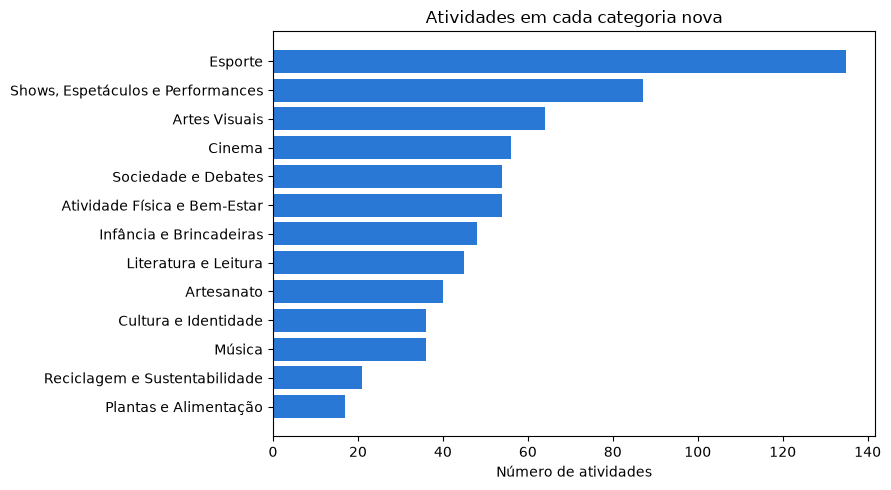

In [13]:
# ----------------------------------------------------------------------------------------------------
#                          GRÁFICO: ATIVIDADES EM CADA CATEGORIA NOVA
# ----------------------------------------------------------------------------------------------------
plt.figure(figsize=(9, 5))                                                                                   # tamanho do gráfico em polegadas
plt.barh(activities_per_new_category.index, activities_per_new_category.values, color="#2a78d6")              # barras deitadas, uma por categoria
plt.gca().invert_yaxis()                                                                                     # categoria maior aparece em cima
plt.xlabel("Número de atividades")                                                                           # rótulo do eixo horizontal
plt.title("Atividades em cada categoria nova")                                                               # título que vai junto no artigo
plt.tight_layout()                                                                                           # evita cortar os nomes das categorias
plt.savefig("../paper/latex/figures/activities_per_new_category.png", dpi=150)                                # figura usada no artigo
plt.show()

In [14]:
clusters_summary.to_csv("../data/processed/clusters_summary.csv", sep=";", index=False, encoding="utf-8-sig")     # resumo com o nome de cada grupo
activities.to_csv("../data/processed/activities_clustered.csv", sep=";", index=False, encoding="utf-8-sig")        # atividades com grupo e categoria nova

print("Tabelas salvas com a categoria nova de cada atividade")
activities[["title", "cluster", "category"]].head(5)

Tabelas salvas com a categoria nova de cada atividade


,title,cluster,category
0,DESESTRESSAR PINTANDO: A ARTE DE RELAXAR COM L...,12,Artes Visuais
1,CONTAÇÃO DE HISTÓRIA: GPS DA ANCESTRALIDADE + ...,9,Infância e Brincadeiras
2,JARDIM SECRETO – UM DIA PLANTANDO SONHOS COM E...,9,Infância e Brincadeiras
3,CRIANDO CURRÍCULO COM FERRAMENTAS DIGITAIS – C...,7,Artesanato
4,OFICINA DE TIRINHA AUTOBIOGRÁFICA PARA POSTAR ...,12,Artes Visuais
